In [24]:
import numpy as np
import pandas as pd
import os
from keras.preprocessing import image
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, MaxPooling2D,MaxPool2D ,UpSampling2D, Flatten, Input
from keras.optimizers import SGD, Adam, Adadelta, Adagrad
from keras import backend as K
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import cv2
from math import log10,sqrt

# **Data Preparation**

This is *Smartphone Image Denoising Dataset* downloaded from,<br>
https://www.eecs.yorku.ca/~kamel/sidd/dataset.php

In [25]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [8]:
train_images=sorted(os.listdir('gdrive/My Drive/Kaggle/CT_COVID'))

FileNotFoundError: [Errno 2] No such file or directory: 'gdrive/My Drive/Kaggle/CT_COVID'

In [ ]:
train_images=sorted(os.listdir('gdrive/My Drive/Kaggle/CT_COVID'))

In [9]:
train_image=[]
for im in train_images:
  img=image.load_img('gdrive/My Drive/Kaggle/CT_COVID/'+im,target_size=(64,64),color_mode='grayscale')
  img=image.img_to_array(img)
  img=img/255
  train_image.append(img)

train_df=np.array(train_image)

NameError: name 'train_images' is not defined

In [10]:
#Subplotting images
def plot_img(dataset):
  f,ax=plt.subplots(1,5)
  f.set_size_inches(40,20)
  for i in range(5,10):
    ax[i-5].imshow(dataset[i].reshape(64,64), cmap='gray')
  plt.show()

In [11]:
#Adding gaussian noise with 0.05 factor
def add_noise(image):
  row,col,ch=image.shape
  mean=0
  sigma=1
  gauss=np.random.normal(mean,sigma,(row,col,ch))
  gauss=gauss.reshape(row,col,ch)
  noisy=image+gauss*0.05
  return noisy

# **EDA**

## **Analysis on the meta-data**

In [12]:
noised_df=[]
for img in train_df:
  noisy=add_noise(img)
  noised_df.append(noisy)

noised_df=np.array(noised_df)

NameError: name 'train_df' is not defined

<font color='purple'>**Observation:**</font>
<br>
We can see that majority of the photos have been clicked on IPhone 7, followed by Samsung S6 and Google Pixel. LG G4 has the least number of photos.

In [13]:
plot_img(train_df)

NameError: name 'train_df' is not defined

IndexError: list index out of range

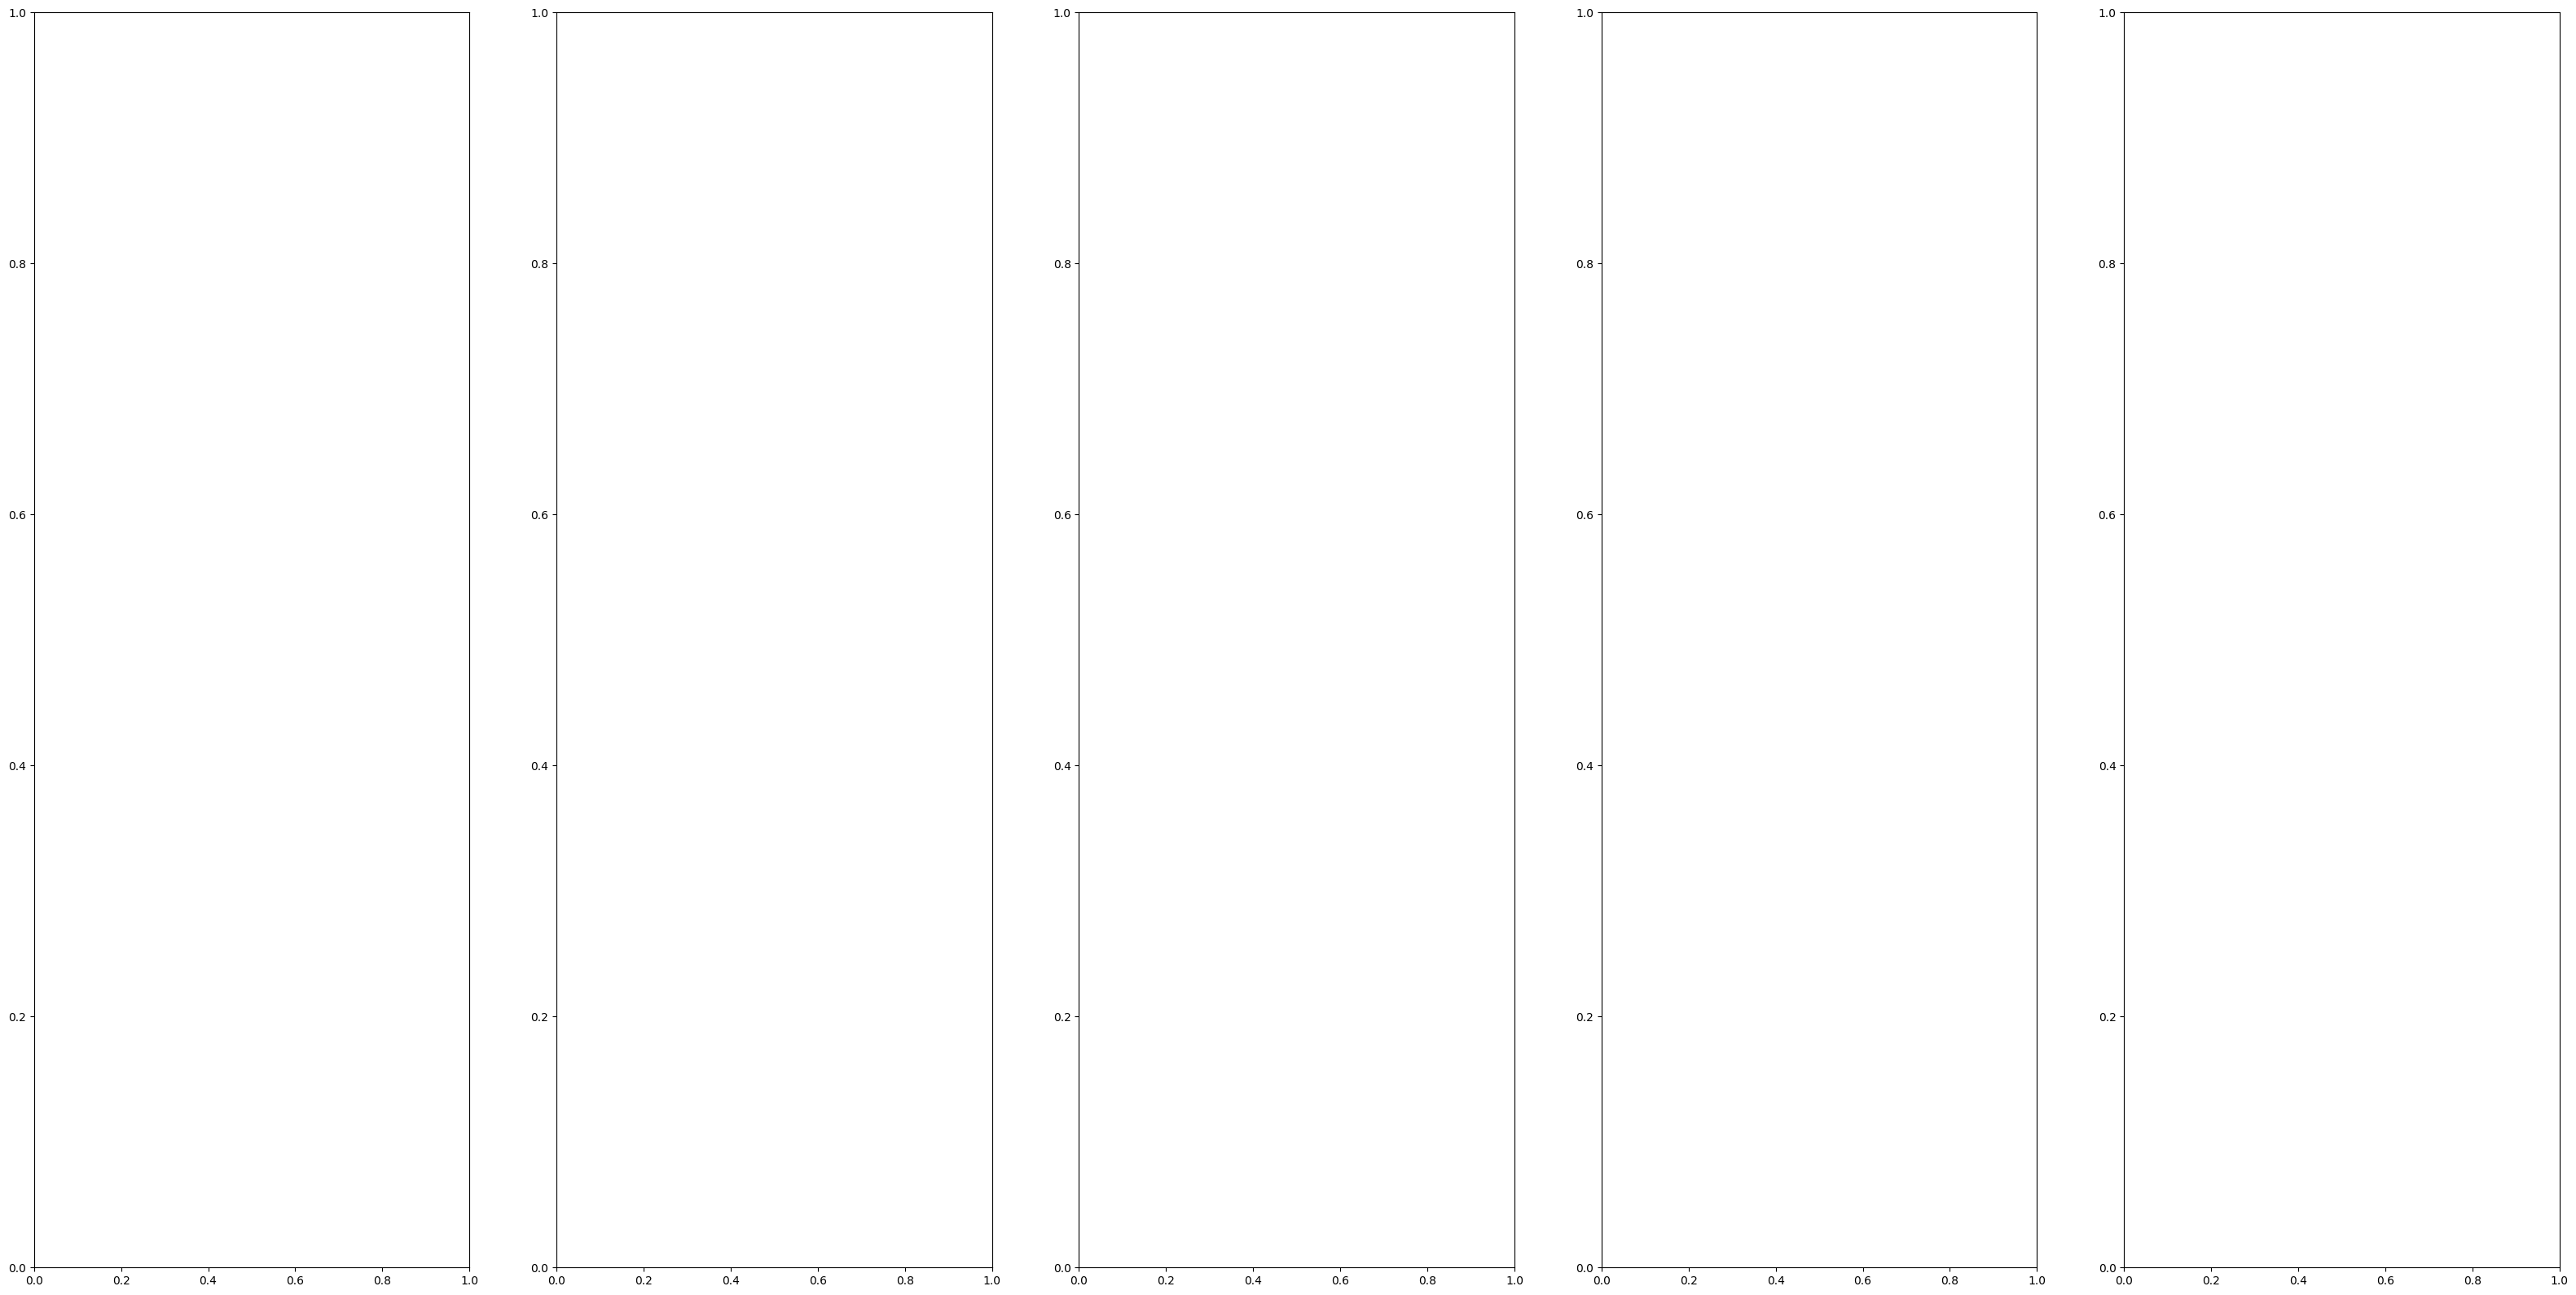

In [14]:
plot_img(noised_df)

In [15]:
xnoised=noised_df[:400]
xtest=noised_df[400:]

<font color='purple'>**Observation:**</font>
<br>
There are total 14 unique ISO level settings used in the dataset. Most of the photos are clicked at a low ISO setting. Most used ISO settings are 100 and 800 followed by 1600,400 and 3200. Higher the exposure, brighter the image will be and vice-versa.

In [16]:
def autoencoder():
  input_img=Input(shape=(64,64,1),name='image_input')
  #enoder
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv1')(input_img)
  x = MaxPooling2D((2,2), padding='same', name='pool1')(x)
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2')(x)
  x = MaxPooling2D((2,2), padding='same', name='pool2')(x)

  #decoder
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv3')(x)
  x = UpSampling2D((2,2), name='upsample1')(x)
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv4')(x)
  x = UpSampling2D((2,2), name='upsample2')(x)
  x = Conv2D(1, (3,3), activation='sigmoid', padding='same', name='Conv5')(x)

  #model
  autoencoder = Model(inputs=input_img, outputs=x)
  autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

  return autoencoder

In [17]:
model= autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 64, 64, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample1 (UpSampling2D)             │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ upsample2 (UpSampling2D)             │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 64, 64, 1)           │             577 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

<font color='purple'>**Observation:**</font>
<br>
Most of the photos are clicked at 100 shutter speed, followed by 400 and 800. Higher the shutter speed darker the image will be, and vice-versa.

In [18]:
with tf.device('/device:GPU:0'):
    early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='auto')
    model.fit(xnoised, xnoised, epochs=18, batch_size=10, validation_data=(xtest, xtest), callbacks=[early_stopping])

KeyError: 'pop from an empty set'

<font color='purple'>**Observation:**</font>
<br>
Majority of the photos are clicked in Normal brightness mode, followed by Low brightness. Only 2 photos are clicked at High brightness on Samsung S6.

In [19]:
xtrain= train_df[100:]

NameError: name 'train_df' is not defined

In [20]:
pred= model.predict(xtest[:5])
def plot_predictions(y_true, y_pred):
    f, ax = plt.subplots(4, 5)
    f.set_size_inches(10.5,7.5)
    for i in range(5):
        ax[0][i].imshow(np.reshape(xtrain[i], (64,64)), aspect='auto', cmap='gray')
        ax[1][i].imshow(np.reshape(y_true[i], (64,64)), aspect='auto', cmap='gray')
        ax[2][i].imshow(np.reshape(y_pred[i], (64,64)), aspect='auto', cmap='gray')
        ax[3][i].imshow(cv2.medianBlur(xtrain[i], (5)), aspect='auto', cmap='gray')
    plt.tight_layout()
plot_predictions(xtest[:5], pred[:5])

KeyError: 'pop from an empty set'

<font color='purple'>**Observation:**</font>
<br>
We can see each phone has its own image resolution. Every individual phone has same resolution photos.

## **Analysis on the Image data**

### Analysing the mean and std deviation on R,G & B channel of all images

In [21]:
median_blur = cv2.medianBlur(xtrain[0], (5))
gaussian_blur=cv2.GaussianBlur(xtrain[0],(5,5),0)
average_blur=cv2.blur(xtrain[0],(5,5))
bilateral_filter=cv2.bilateralFilter(xtrain[0],9,75,75)
f,ax=plt.subplots(1,5)
f.set_size_inches(40,20)
ax[0].imshow(pred[0].reshape(64,64), cmap='gray')
ax[0].set_title('Autoencoder Image')
ax[1].imshow(median_blur,cmap='gray')
ax[1].set_title('Median Filter')
ax[2].imshow(gaussian_blur,cmap='gray')
ax[2].set_title('Gaussian Filter')
ax[3].imshow(average_blur,cmap='gray')
ax[3].set_title('Average Filter')
ax[4].imshow(bilateral_filter,cmap='gray')
ax[4].set_title('Bilateral Filter')

NameError: name 'xtrain' is not defined

In [22]:
Text(0.5, 1.0, 'Bilateral Filter')

NameError: name 'Text' is not defined

In [23]:
def PSNR(original, denoised):
    mse = np.mean((original - denoised) ** 2)
    if(mse == 0):
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr


value1 = PSNR(xtest[0], median_blur)
value2 = PSNR(xtest[0], pred[0])
value3 = PSNR(xtest[0], gaussian_blur)
value4 = PSNR(xtest[0], average_blur)
value5 = PSNR(xtest[0], bilateral_filter)

print("PSNR values")
print(f"Autoencoder Image : {value2} dB")
print(f"Median Filter Image : {value1} dB")
print(f"Gaussian Filter Image : {value3} dB")
print(f"Average Filter Image : {value4} dB")
print(f"Bilateral Filter Image : {value5} dB")

IndexError: list index out of range

<font color='purple'>**Observation:**</font>
<br>
It is seen that most of the mean pixel values are at a lower to medium value (darker to medium brightness images). Only few of them are very high value(bright images)

Text(0.5, 1.0, 'Ground truth images pixel intensity distribution')

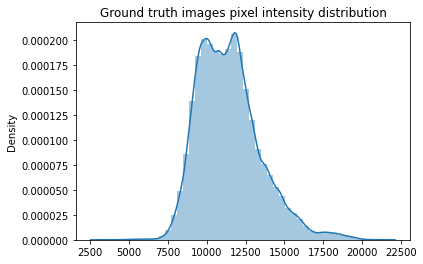

<font color='purple'>**Observation:**</font>
<br>
Thorugh this we can confirm that pixel intensities of all the images is similar and almost normally distributed.

<font color='purple'>**Observation:**</font>
<br>
It can be observed that the noisy images has smooth distribution of pixel intensity as compared to the original images. The reason for this is that, whenever there is noise in an image, it means the camera has failed to capture the color info for those pixels (due to various reasons) and hence, to fill the 'no color' in those pixels, it is filled with some random value by the camera software. Due to this random values (noise) the pixel values gets smoothed out.